In [1]:
import inspect
import torch
import torch.utils._pytree as _torch_pytree


if (not hasattr(_torch_pytree, "register_pytree_node")
    and hasattr(_torch_pytree, "_register_pytree_node")):
    _old_register = _torch_pytree._register_pytree_node
    _old_params = set(inspect.signature(_old_register).parameters)

    def register_pytree_node_compat(
        cls,flatten_fn,unflatten_fn,**kwargs,):
        allowed_kwargs = {k: v
            for k, v in kwargs.items()
            if k in _old_params}

        return _old_register(cls,flatten_fn,unflatten_fn,**allowed_kwargs,)

    _torch_pytree.register_pytree_node = register_pytree_node_compat

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score

from config import make_config
from datasets import build_dataset, build_dataset_xonly_delay
from models import build_model_from_cfg
from train import train_model
from detectors import (
    calibrate_gate_platt_adaptive_constrained,
    apply_platt_to_gate,
    fit_posthoc_unpredictable_classifier,
    apply_posthoc_classifier)
from inference import selective_rollout_numpy,  forced_rollout_numpy, corrected_rollout_numpy
from metrics import print_metrics, print_posthoc_detector_metrics, make_required_metrics_table
from attractor_generate import simulate_lorenz, simulate_rossler, plot_attractor_with_timeseries
from visualization import plot_prediction_example


c:\Foranac\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


# Attractor vizualisation

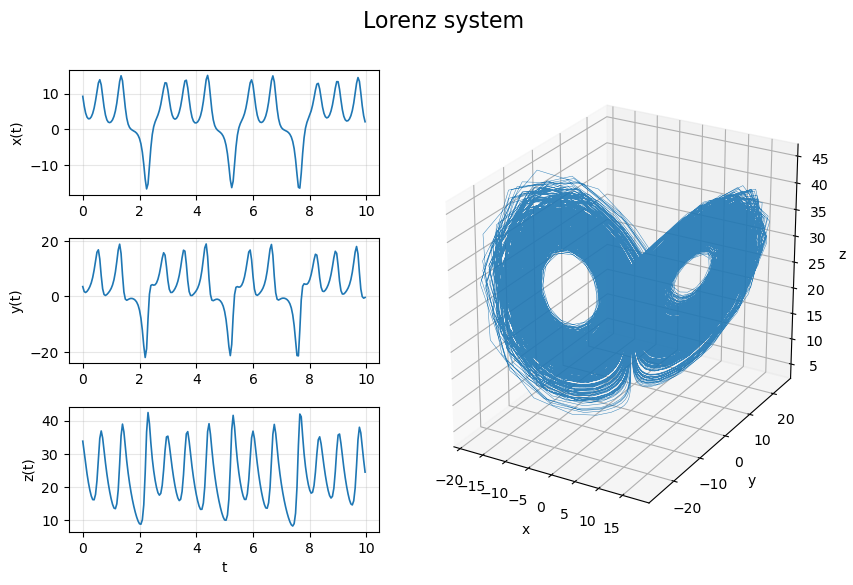

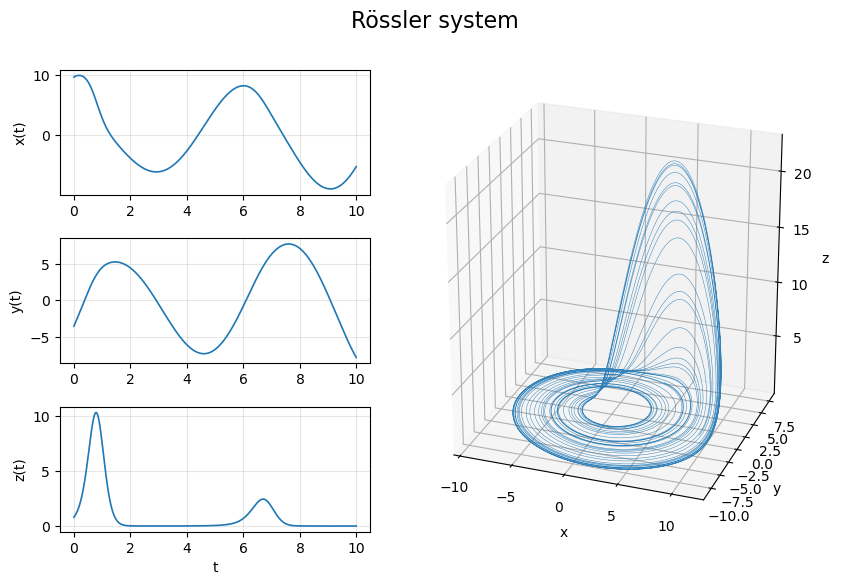

In [3]:
lorenz_dt = 0.05
rossler_dt = 0.01

lorenz_data = simulate_lorenz(dt=lorenz_dt,t_total=1000.0,t_transient=100.0,)

rossler_data = simulate_rossler(dt=rossler_dt,t_total=1000.0,t_transient=100.0,)

plot_attractor_with_timeseries(data=lorenz_data,dt=lorenz_dt,n_ts=200,n_3d=12_000,title="Lorenz system",
    filename="lorenz_attractor.png",view_elev=25,view_azim=-60)

plot_attractor_with_timeseries(data=rossler_data,dt=rossler_dt,n_ts=1000,n_3d=20_000,title="Rössler system",
    filename="rossler_attractor.png",view_elev=25,view_azim=-70)

# Lorenz

## Lorenz full phase detector out

loaded weights: ./checkpoints/lorenz_full_phase_posthoc_njode_best.pt
LORENZ POSTHOC MDN-STATS TEST RESULTS

[X metrics]
Short RMSE-x (0:20)             : 0.3536
Long  RMSE-x (20:end)           : 1.3093
Full  RMSE-x                           : 1.2472
Amplitude ratio x                      : 0.9518
Switching true / pred / ratio          : 0.0367 / 0.0345 / 0.9387
Spectral distance on x-long            : 0.048007
Valid Time-x @0.2/0.4/0.8              : 1.016 / 1.556 / 2.130

[Full-phase metrics]
Short RMSE all coords (0:20)     : 0.3570
Long  RMSE all coords (20:end)   : 1.3180
Full  RMSE all coords                  : 1.2555
Coord RMSE                             : [1.247153  1.2597545 1.259484 ]
Amplitude ratio                        : [0.95180345 0.93884784 0.9816592 ]
Switching true / pred / ratio          : 0.0367 / 0.0345 / 0.9387
Spectral distance on x-long            : 0.048007
Valid Time all @0.2/0.4/0.8            : 0.912 / 1.400 / 1.950
posthoc classifier info: {'positive_rate

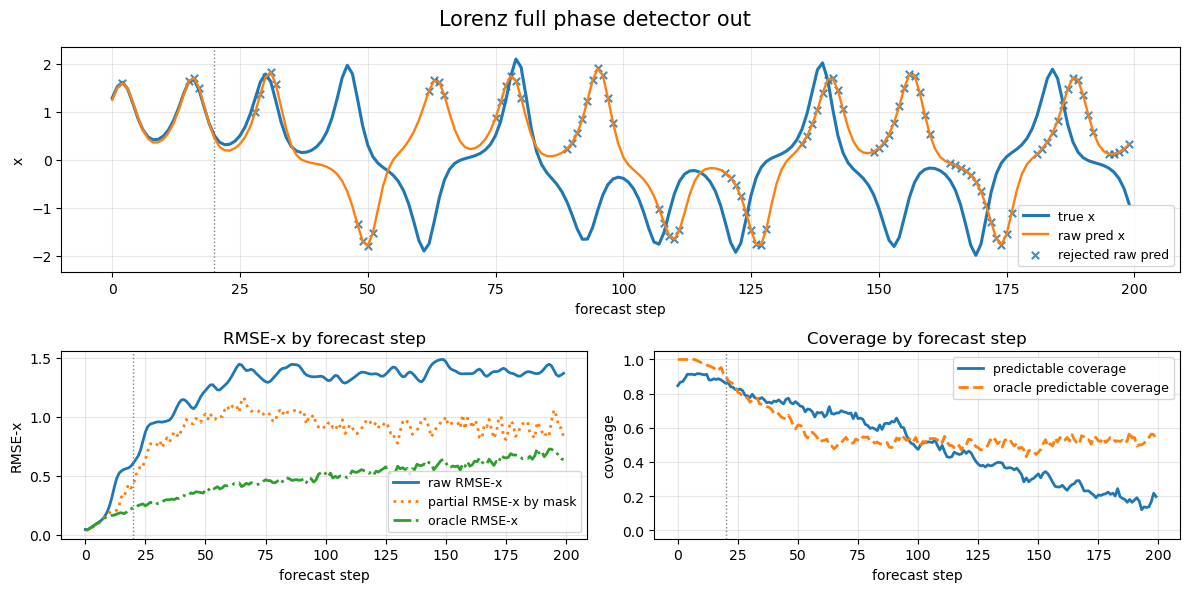

In [ ]:
cfg = make_config(attractor="lorenz",task="full_phase",detector="posthoc",save_dir="./checkpoints",)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset(cfg)

model = build_model_from_cfg(cfg).to(device)

if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path,weights_only=False,map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    print("loaded weights:", cfg.best_weights_path)

else:
    model, history = train_model(model, X_train, Y_train, X_val, Y_val,cfg,log_every=100,)

N_VIS = 300

rollout_test = forced_rollout_numpy(model,X_test,cfg,Y=Y_test,n_samples=N_VIS,)

pred_np = rollout_test["pred"]
true_np = rollout_test["true"]

metrics_l_full_out = print_metrics(pred=pred_np, true=true_np, cfg=cfg, name=f"{cfg.attractor.name.upper()} POSTHOC MDN-STATS TEST RESULTS")


rollout_val = forced_rollout_numpy(model, X_val, cfg, Y=Y_val, n_samples=2048,)

clf, clf_info = fit_posthoc_unpredictable_classifier(rollout_val, cfg, adaptive=True,)

print("posthoc classifier info:", clf_info)

proba_unpred = apply_posthoc_classifier(clf, rollout_test)


det_metrics_l_full_out = print_posthoc_detector_metrics(proba_unpred, pred_np, true_np, cfg, threshold=0.5, adaptive=True,)

plot_info = plot_prediction_example(
    pred=pred_np,true=true_np,
    cfg=cfg,idx=149,proba_unpred=proba_unpred,        
    corrected_pred=None,
    threshold=0.5,
    mode="posthoc",
    name="Lorenz full phase detector out",)

## Lorenz x-only detector out

loaded weights: ./checkpoints/lorenz_x_delay_posthoc_njode_best.pt
LORENZ POSTHOC MDN-STATS TEST RESULTS

[X metrics]
Short RMSE-x (0:20)             : 0.2626
Long  RMSE-x (20:end)           : 1.2607
Full  RMSE-x                           : 1.1988
Amplitude ratio x                      : 0.9533
Switching true / pred / ratio          : 0.0382 / 0.0358 / 0.9367
Spectral distance on x-long            : 0.043370
Valid Time-x @0.2/0.4/0.8              : 1.080 / 1.766 / 2.562
posthoc classifier info: {'positive_rate': 0.3118994140625, 'auc': 0.757710918365782, 'ap': 0.5416196138504233}
POST-HOC UNPREDICTABLE DETECTOR
AUC / AP                       : 0.7594 / 0.5091
threshold                      : 0.500
precision unpredictable         : 0.4844
recall unpredictable            : 0.7049
partial RMSE-x predicted reliable : 0.6781
predictable coverage            : 0.5872
daemon predictable coverage     : 0.7163
daemon unpredictable rate       : 0.2837
daemon RMSE-x predictable       : 0.3967


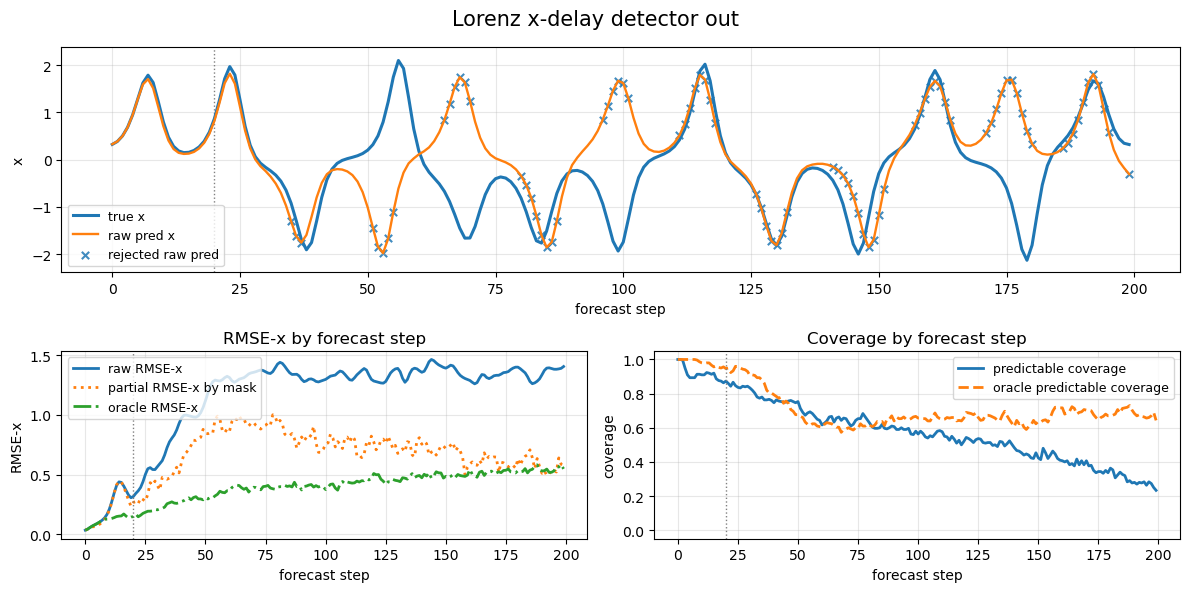

In [ ]:
cfg = make_config(attractor="lorenz",task="x_delay",detector="posthoc",save_dir="./checkpoints",)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset_xonly_delay(cfg)

model = build_model_from_cfg(cfg).to(device)

if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path,weights_only=False,map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    print("loaded weights:", cfg.best_weights_path)

else:
    model, history = train_model(model,X_train,Y_train,X_val, Y_val,cfg,log_every=100,)

N_VIS = 300

rollout_test = forced_rollout_numpy(model,X_test,cfg,Y=Y_test,n_samples=N_VIS,)

pred_np = rollout_test["pred"]
true_np = rollout_test["true"]

metrics_l_x_out = print_metrics(pred=pred_np, true=true_np, cfg=cfg, name=f"{cfg.attractor.name.upper()} POSTHOC MDN-STATS TEST RESULTS")


rollout_val = forced_rollout_numpy(model,X_val,cfg,Y=Y_val,n_samples=2048,)

clf, clf_info = fit_posthoc_unpredictable_classifier(rollout_val,cfg,adaptive=True,)

print("posthoc classifier info:", clf_info)

proba_unpred = apply_posthoc_classifier(clf,rollout_test)

det_metrics_l_x_out = print_posthoc_detector_metrics(proba_unpred, pred_np, true_np, cfg, threshold=0.5, adaptive=True,)

plot_info = plot_prediction_example(
    pred=pred_np,true=true_np,
    cfg=cfg,idx=149,
    proba_unpred=proba_unpred,        
    corrected_pred=None,
    threshold=0.5,
    mode="posthoc",
    name="Lorenz x-delay detector out")

## Lorenz full phase detector in

loaded weights: ./checkpoints/lorenz_full_phase_selective_njode_best.pt
calibrated threshold: 0.5901337792642141
calibration info: {'threshold': 0.5901337792642141, 'precision': 0.8009915014164306, 'recall': 0.7445581395348837, 'coverage': 0.634296875, 'TP': 208104, 'FP': 51704, 'FN': 71396}
LORENZ SELECTIVE NJODE TEST RESULTS

[X metrics]
Short RMSE-x (0:20)             : 0.0747
Long  RMSE-x (20:end)           : 1.2910
Full  RMSE-x                           : 1.2250
Amplitude ratio x                      : 0.9767
Switching true / pred / ratio          : 0.0367 / 0.0456 / 1.2407
Spectral distance on x-long            : 0.057588
Valid Time-x @0.2/0.4/0.8              : 1.502 / 1.952 / 2.411

[Full-phase metrics]
Short RMSE all coords (0:20)     : 0.0854
Long  RMSE all coords (20:end)   : 1.2078
Full  RMSE all coords                  : 1.1461
Coord RMSE                             : [1.2250029  1.243214   0.94577193]
Amplitude ratio                        : [0.9767112 0.9670894 0.9868055

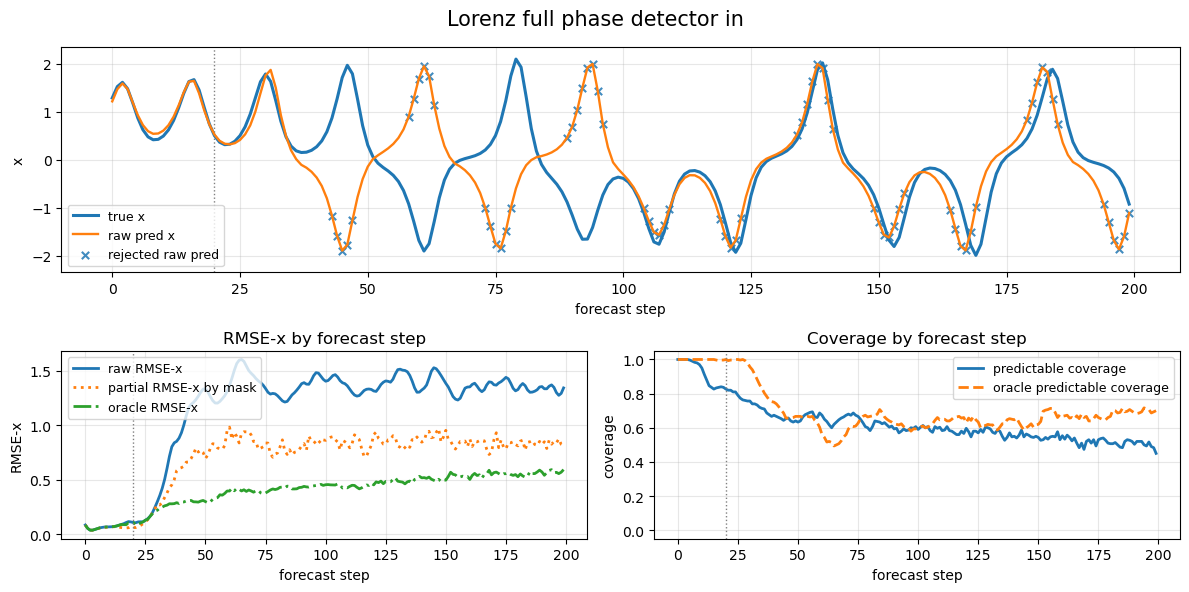

In [6]:
cfg = make_config(attractor="lorenz",task="full_phase",detector="selective",save_dir="./checkpoints",)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset(cfg)

model = build_model_from_cfg(cfg).to(device)


if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path,weights_only=False,map_location=device,)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    print("loaded weights:", cfg.best_weights_path)

else:
    model = train_model(model,X_train,Y_train,X_val,Y_val,cfg,log_every=100,use_adaptive_oracle=False,div_weight=0.0,)

gate_threshold, platt_lr, calib_info = calibrate_gate_platt_adaptive_constrained(
    model,X_val,Y_val,cfg,n_samples=2048,)

print("calibrated threshold:", gate_threshold)
print("calibration info:", calib_info)

N_VIS = 300

pred_np, partial_pred_np, true_np, gate_np, mask_np, aux = selective_rollout_numpy(
    model, X_test, cfg, Y=Y_test,
    n_samples=N_VIS,gate_threshold=0.0, sample_mode=False,return_aux=True)

err_hat_np = aux["err_hat"]

gate_cal_np = apply_platt_to_gate(gate_np, platt_lr)
mask_cal_np = gate_cal_np >= gate_threshold

corrected_pred_np, true_np, gate_used_np, aux = corrected_rollout_numpy(model,
    X_test, cfg, Y=Y_test, n_samples=300, threshold=gate_threshold, mode="selective", platt_model=platt_lr, replacement="mdn_map",)

metrics_l_full_in = print_metrics(pred=pred_np,true=true_np,gate=gate_cal_np,cfg=cfg,
    gate_threshold=gate_threshold,
    name=f"{cfg.attractor.name.upper()} SELECTIVE NJODE TEST RESULTS")

plot_info = plot_prediction_example(pred=pred_np,true=true_np,cfg=cfg,
    idx=149, gate=gate_cal_np, corrected_pred=None,
    threshold=gate_threshold, mode="selective",
    name="Lorenz full phase detector in")

## Lorenx x-only detector in

loaded weights: ./checkpoints/lorenz_x_delay_selective_njode_best.pt
calibrated threshold: 0.6392976588628763
calibration info: {'threshold': 0.6392976588628763, 'precision': 0.8013398779517114, 'recall': 0.651866754541145, 'coverage': 0.51529296875, 'TP': 169134, 'FP': 41930, 'FN': 90327}
LORENZ SELECTIVE NJODE TEST RESULTS

[X metrics]
Short RMSE-x (0:20)             : 0.1107
Long  RMSE-x (20:end)           : 1.3496
Full  RMSE-x                           : 1.2808
Amplitude ratio x                      : 0.9672
Switching true / pred / ratio          : 0.0382 / 0.0400 / 1.0453
Spectral distance on x-long            : 0.081238
Valid Time-x @0.2/0.4/0.8              : 1.134 / 1.664 / 2.250

[Selective / gate metrics]
Gate threshold                         : 0.6393
Adaptive eps x                         : 0.600 → 1.200
Full recursive RMSE-x, all points      : 1.2808
Partial RMSE-x, gate-selected points   : 0.7336
Coverage                               : 0.515
Nonpredictable share         

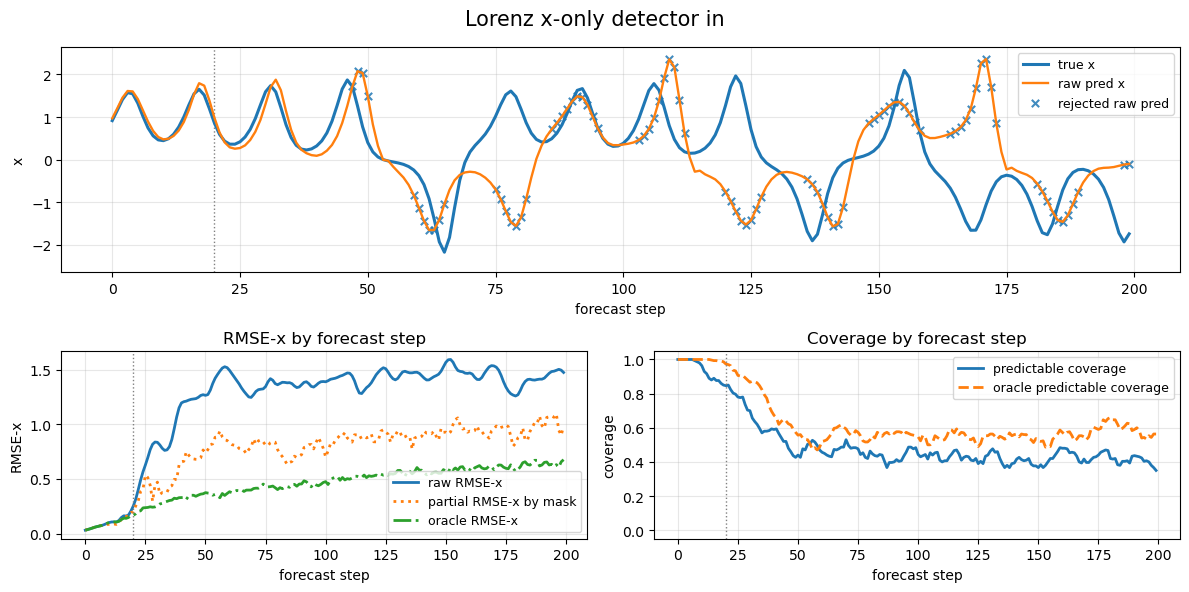

In [7]:
cfg = make_config(attractor="lorenz",task="x_delay",detector="selective",save_dir="./checkpoints")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset_xonly_delay(cfg)

model = build_model_from_cfg(cfg).to(device)


if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path, weights_only=False, map_location=device,)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
    print("loaded weights:", cfg.best_weights_path)
else:
    model = train_model(model, X_train, Y_train, X_val, Y_val,
        cfg, log_every=100, use_adaptive_oracle=False, div_weight=0.0,)

gate_threshold, platt_lr, calib_info = calibrate_gate_platt_adaptive_constrained(model,X_val,Y_val,cfg,n_samples=2048)

print("calibrated threshold:", gate_threshold)
print("calibration info:", calib_info)


N_VIS = 300

pred_np, partial_pred_np, true_np, gate_np, mask_np, aux = selective_rollout_numpy( model,X_test,cfg,
    Y=Y_test,n_samples=N_VIS,gate_threshold=0.0,  sample_mode=False,return_aux=True)

err_hat_np = aux["err_hat"]

gate_cal_np = apply_platt_to_gate(gate_np, platt_lr)
mask_cal_np = gate_cal_np >= gate_threshold


metrics_l_x_in = print_metrics( pred=pred_np,true=true_np,gate=gate_cal_np,cfg=cfg,gate_threshold=gate_threshold,
    name=f"{cfg.attractor.name.upper()} SELECTIVE NJODE TEST RESULTS")

corrected_pred_np, true_np, gate_used_np, aux = corrected_rollout_numpy(model,
    X_test, cfg, Y=Y_test, n_samples=300,
    threshold=gate_threshold, mode="selective",
    platt_model=platt_lr, replacement="mdn_map",)

plot_info = plot_prediction_example(
    pred=pred_np, true=true_np, cfg=cfg,
    idx=50, gate=gate_cal_np,
    corrected_pred=None,
    threshold=gate_threshold,
    mode="selective",name="Lorenz x-only detector in",)


# Rossler

## Rossler full phase detector out

loaded weights: ./checkpoints/rossler_full_phase_posthoc_njode_best.pt
ROSSLER POSTHOC MDN-STATS TEST RESULTS

[X metrics]
Short RMSE-x (0:30)             : 0.0565
Long  RMSE-x (30:end)           : 0.3917
Full  RMSE-x                           : 0.3720
Amplitude ratio x                      : 0.9940
Switching true / pred / ratio          : 0.0173 / 0.0171 / 0.9892
Spectral distance on x-long            : 0.003442
Valid Time-x @0.2/0.4/0.8              : 3.857 / 7.019 / 12.820

[Full-phase metrics]
Short RMSE all coords (0:30)     : 0.0605
Long  RMSE all coords (30:end)   : 0.6020
Full  RMSE all coords                  : 0.5714
Coord RMSE                             : [0.37199426 0.33462864 0.85383254]
Amplitude ratio                        : [0.9939763 1.006456  0.8374952]
Switching true / pred / ratio          : 0.0173 / 0.0171 / 0.9892
Spectral distance on x-long            : 0.003442
Valid Time all @0.2/0.4/0.8            : 3.584 / 6.647 / 9.069
posthoc classifier info: {'positive_r

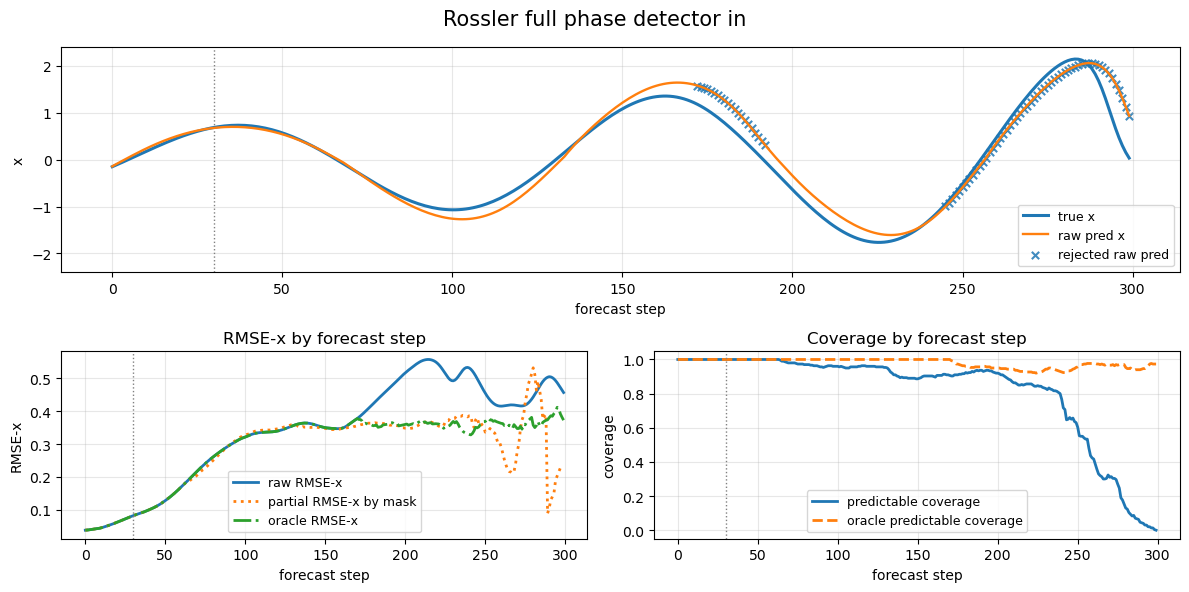

In [8]:
cfg = make_config(attractor="rossler",task="full_phase",detector="posthoc",save_dir="./checkpoints",)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset(cfg)

model = build_model_from_cfg(cfg).to(device)

if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path,weights_only=False,map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    print("loaded weights:", cfg.best_weights_path)

else:
    model, history = train_model(model,X_train,Y_train,X_val, Y_val,cfg,log_every=100,)

N_VIS = 300

rollout_test = forced_rollout_numpy(model,X_test,cfg,Y=Y_test,n_samples=N_VIS,)

pred_np = rollout_test["pred"]
true_np = rollout_test["true"]

metrics_r_full_out = print_metrics(pred=pred_np,true=true_np,cfg=cfg,name=f"{cfg.attractor.name.upper()} POSTHOC MDN-STATS TEST RESULTS")


rollout_val = forced_rollout_numpy(model,X_val,cfg,Y=Y_val,n_samples=2048,)

clf, clf_info = fit_posthoc_unpredictable_classifier(rollout_val, cfg, adaptive=True,)

print("posthoc classifier info:", clf_info)

proba_unpred = apply_posthoc_classifier(clf,rollout_test)


det_metrics_r_full_out = print_posthoc_detector_metrics(proba_unpred, pred_np, true_np, cfg, threshold=0.5, adaptive=True,)

plot_info = plot_prediction_example(pred=pred_np,
    true=true_np, cfg=cfg,
    idx=1, proba_unpred=proba_unpred, corrected_pred=None,
    threshold=0.5, mode="posthoc",
    name="Rossler full phase detector in")


## Rossler x delay detector out

loaded weights: ./checkpoints/rossler_x_delay_posthoc_njode_best.pt
ROSSLER POSTHOC MDN-STATS TEST RESULTS

[X metrics]
Short RMSE-x (0:30)             : 0.0406
Long  RMSE-x (30:end)           : 0.2758
Full  RMSE-x                           : 0.2620
Amplitude ratio x                      : 1.0507
Switching true / pred / ratio          : 0.0171 / 0.0169 / 0.9877
Spectral distance on x-long            : 0.000547
Valid Time-x @0.2/0.4/0.8              : 8.592 / 11.079 / 14.857
posthoc classifier info: {'positive_rate': 3.580729166666667e-05, 'auc': 0.9996840855156095, 'ap': 0.05521557952505881}
POST-HOC UNPREDICTABLE DETECTOR
AUC / AP                       : nan / nan
threshold                      : 0.500
precision unpredictable         : 0.0000
recall unpredictable            : 0.0000
partial RMSE-x predicted reliable : 0.2591
predictable coverage            : 0.9953
daemon predictable coverage     : 1.0000
daemon unpredictable rate       : 0.0000
daemon RMSE-x predictable       : 0.262

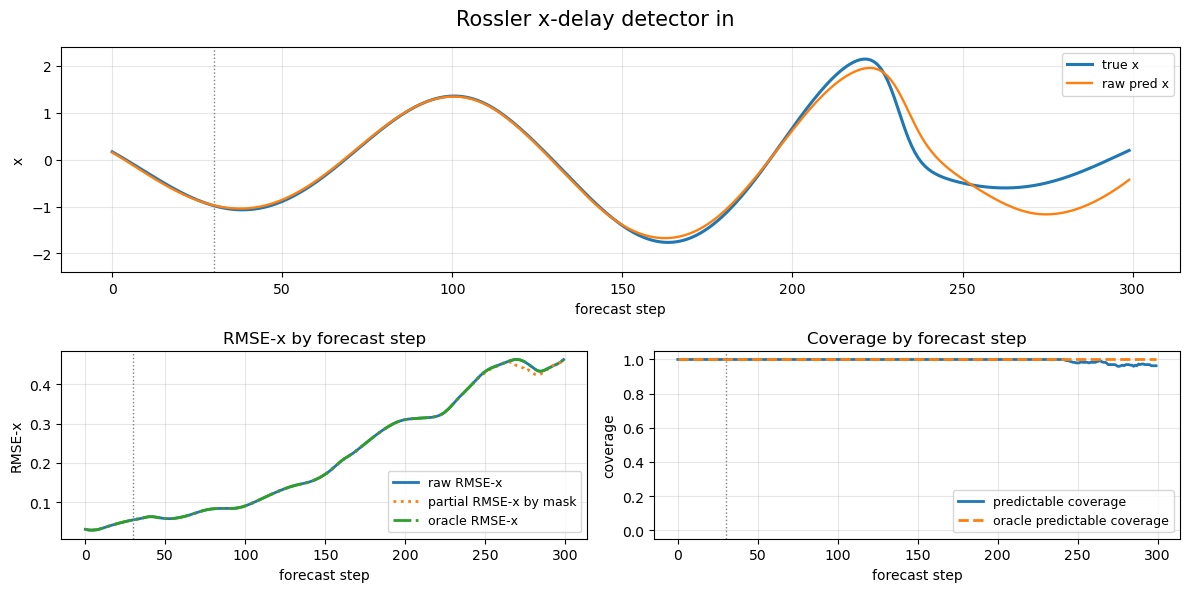

In [9]:
cfg = make_config(attractor="rossler",task="x_delay",detector="posthoc",save_dir="./checkpoints",)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset_xonly_delay(cfg)

model = build_model_from_cfg(cfg).to(device)

if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path,weights_only=False,map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    print("loaded weights:", cfg.best_weights_path)

else:
    model, history = train_model(model,X_train,Y_train,X_val, Y_val,cfg,log_every=100,)

N_VIS = 300

rollout_test = forced_rollout_numpy(model,X_test,cfg,Y=Y_test,n_samples=N_VIS,)

pred_np = rollout_test["pred"]
true_np = rollout_test["true"]

metrics_r_x_out = print_metrics(pred=pred_np,true=true_np,cfg=cfg,name=f"{cfg.attractor.name.upper()} POSTHOC MDN-STATS TEST RESULTS")


rollout_val = forced_rollout_numpy(model,X_val,cfg,Y=Y_val,n_samples=2048,)

clf, clf_info = fit_posthoc_unpredictable_classifier(rollout_val,cfg,adaptive=True,)

print("posthoc classifier info:", clf_info)

proba_unpred = apply_posthoc_classifier(clf,rollout_test)

det_metrics_r_x_out = print_posthoc_detector_metrics(proba_unpred,pred_np,true_np,cfg,threshold=0.5,adaptive=True,)

plot_info = plot_prediction_example(
    pred=pred_np, true=true_np,cfg=cfg,
    idx=1, proba_unpred=proba_unpred,        
    corrected_pred=None, threshold=0.5,
    mode="posthoc", name="Rossler x-delay detector in")

## Rossler full phase detector in

loaded weights: ./checkpoints/rossler_full_phase_selective_njode_best.pt
calibrated threshold: 0.7179598662207357
calibration info: {'threshold': 0.7179598662207357, 'precision': 0.8060674852354164, 'recall': 0.6638398800397944, 'coverage': 0.5577994791666666, 'TP': 276249, 'FP': 66463, 'FN': 139889}
ROSSLER SELECTIVE NJODE TEST RESULTS

[X metrics]
Short RMSE-x (0:30)             : 0.1762
Long  RMSE-x (30:end)           : 1.0821
Full  RMSE-x                           : 1.0281
Amplitude ratio x                      : 1.1563
Switching true / pred / ratio          : 0.0173 / 0.0195 / 1.1298
Spectral distance on x-long            : 0.040098
Valid Time-x @0.2/0.4/0.8              : 1.514 / 2.735 / 5.582

[Full-phase metrics]
Short RMSE all coords (0:30)     : 0.2075
Long  RMSE all coords (30:end)   : 1.3282
Full  RMSE all coords                  : 1.2618
Coord RMSE                             : [1.0280402  0.89707756 1.707036  ]
Amplitude ratio                        : [1.1562493 0.9335525

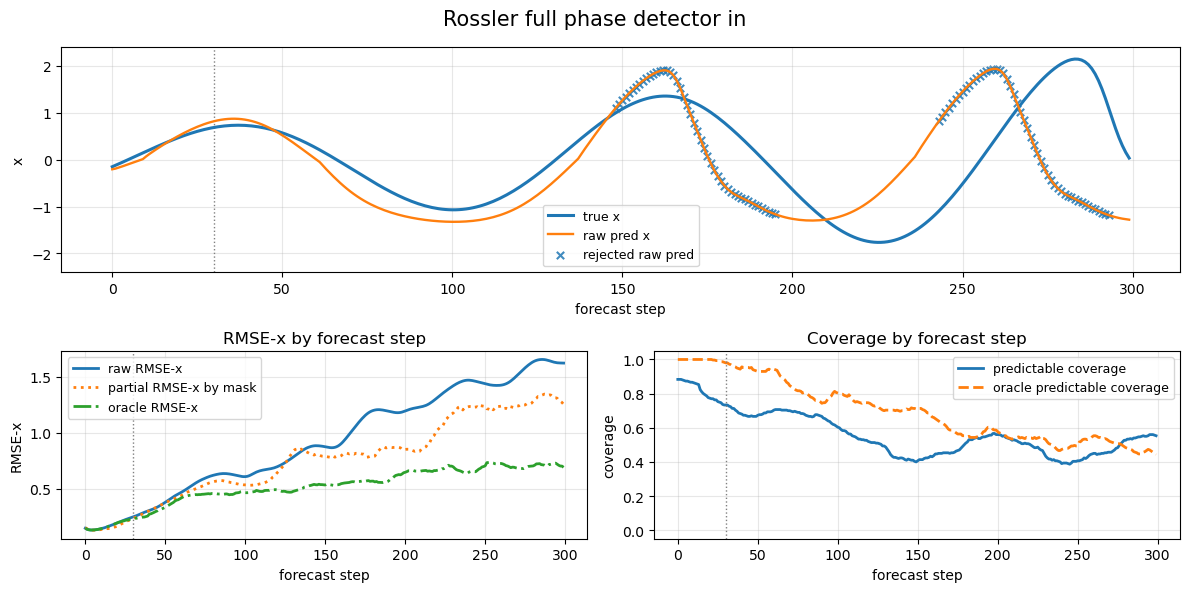

In [10]:
cfg = make_config(attractor="rossler",task="full_phase",detector="selective",save_dir="./checkpoints")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset(cfg)

model = build_model_from_cfg(cfg).to(device)

if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path,weights_only=False, map_location=device,)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    print("loaded weights:", cfg.best_weights_path)

else:
    model = train_model(model, X_train, Y_train, X_val, Y_val, cfg, log_every=100, use_adaptive_oracle=False, div_weight=0.0)

gate_threshold, platt_lr, calib_info = calibrate_gate_platt_adaptive_constrained(model,X_val,Y_val,cfg,n_samples=2048)

print("calibrated threshold:", gate_threshold)
print("calibration info:", calib_info)

N_VIS = 300

pred_np, partial_pred_np, true_np, gate_np, mask_np, aux = selective_rollout_numpy(model,X_test,cfg,
    Y=Y_test,n_samples=N_VIS,gate_threshold=0.0, sample_mode=False,return_aux=True,)

err_hat_np = aux["err_hat"]

gate_cal_np = apply_platt_to_gate(gate_np, platt_lr)
mask_cal_np = gate_cal_np >= gate_threshold


metrics_r_full_in = print_metrics(pred=pred_np,true=true_np,
    gate=gate_cal_np,cfg=cfg,gate_threshold=gate_threshold,
    name=f"{cfg.attractor.name.upper()} SELECTIVE NJODE TEST RESULTS",)

plot_info = plot_prediction_example(
    pred=pred_np, true=true_np, cfg=cfg,
    idx=1, gate=gate_cal_np,
    corrected_pred=None,
    threshold=gate_threshold,
    mode="selective",
    name="Rossler full phase detector in",)


## Rossler x_delay detector in

loaded weights: ./checkpoints/rossler_x_delay_selective_njode_best.pt
calibrated threshold: 0.01
calibration info: {'threshold': 0.01, 'precision': 0.9572965494791666, 'recall': 1.0, 'coverage': 1.0, 'TP': 588163, 'FP': 26237, 'FN': 0}
ROSSLER SELECTIVE NJODE TEST RESULTS

[X metrics]
Short RMSE-x (0:30)             : 0.0891
Long  RMSE-x (30:end)           : 0.5424
Full  RMSE-x                           : 0.5153
Amplitude ratio x                      : 1.0988
Switching true / pred / ratio          : 0.0171 / 0.0166 / 0.9697
Spectral distance on x-long            : 0.019430
Valid Time-x @0.2/0.4/0.8              : 3.287 / 4.947 / 11.004

[Selective / gate metrics]
Gate threshold                         : 0.0100
Adaptive eps x                         : 0.600 → 1.200
Full recursive RMSE-x, all points      : 0.5153
Partial RMSE-x, gate-selected points   : 0.5153
Coverage                               : 1.000
Nonpredictable share                   : 0.000
Adaptive daemon coverage           

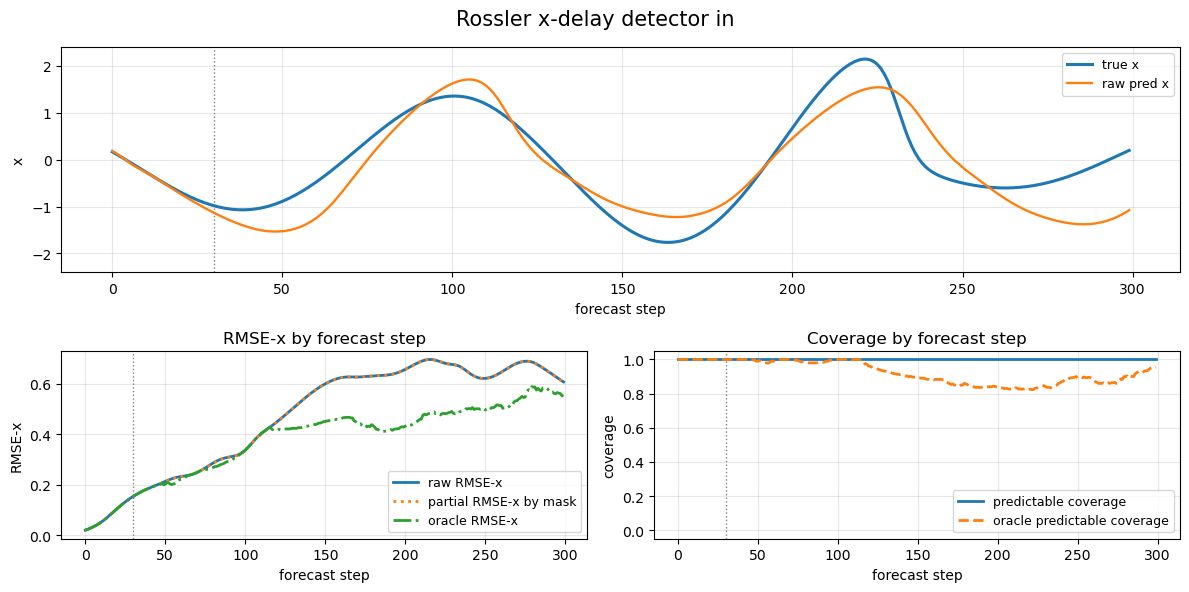

In [11]:
cfg = make_config(attractor="rossler", task="x_delay", detector="selective", save_dir="./checkpoints")

X_train, Y_train, X_val, Y_val, X_test, Y_test, mean, std = build_dataset_xonly_delay(cfg)

model = build_model_from_cfg(cfg).to(device)


if os.path.exists(cfg.best_weights_path):
    checkpoint = torch.load(cfg.best_weights_path, weights_only=False, map_location=device,)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
    print("loaded weights:", cfg.best_weights_path)
else:
    model = train_model(model, X_train, Y_train, X_val, Y_val,
        cfg, log_every=100, use_adaptive_oracle=False, div_weight=0.0,)

gate_threshold, platt_lr, calib_info = calibrate_gate_platt_adaptive_constrained(model, X_val, Y_val, cfg, n_samples=2048)

print("calibrated threshold:", gate_threshold)
print("calibration info:", calib_info)


N_VIS = 300

pred_np, partial_pred_np, true_np, gate_np, mask_np, aux = selective_rollout_numpy( model,X_test,cfg,
    Y=Y_test,n_samples=N_VIS,gate_threshold=0.0,  sample_mode=False,return_aux=True)

err_hat_np = aux["err_hat"]

gate_cal_np = apply_platt_to_gate(gate_np, platt_lr)
mask_cal_np = gate_cal_np >= gate_threshold


metrics_r_x_in = print_metrics( pred=pred_np, true=true_np, gate=gate_cal_np, cfg=cfg,gate_threshold=gate_threshold,
    name=f"{cfg.attractor.name.upper()} SELECTIVE NJODE TEST RESULTS")

plot_info = plot_prediction_example(
    pred=pred_np, true=true_np,
    cfg=cfg, idx=1,
    gate=gate_cal_np,
    corrected_pred=None,
    threshold=gate_threshold,
    mode="selective",
    name="Rossler x-delay detector in")


# Comparison

In [12]:
results_lorenz = {
    "full_phase_out": (metrics_l_full_out,det_metrics_l_full_out),
    "x_out": (metrics_l_x_out,det_metrics_l_x_out),
    "full_phase_in": metrics_l_full_in,
    "x_in": metrics_l_x_in}


results_rossler = {
    "full_phase_out": (metrics_r_full_out,det_metrics_r_full_out),
    "x_out": (metrics_r_x_out,det_metrics_r_x_out),
    "full_phase_in": metrics_r_full_in,
    "x_in": metrics_r_x_in,}

In [13]:
df_compare_l = make_required_metrics_table(
    results_lorenz,
    sort_by="valid_time_x_04",
    ascending=False,)

df_compare_l

,model,short_rmse_x,long_rmse_x,full_rmse_x,partial_rmse_x,amp_ratio_x,switching_true,switching_pred,switching_ratio,spectral_distance_x,valid_time_x_02,valid_time_x_04,valid_time_x_08,coverage,daemon_coverage,daemon_rmse_x,precision,recall
0,full_phase_in,0.0747,1.2910,1.2250,0.7202,0.9767,0.0367,0.0456,1.2407,0.0576,1.5022,1.9515,2.4107,0.6327,0.7071,0.4098,0.8348,0.7469
1,x_out,0.2626,1.2607,1.1988,0.6781,0.9533,0.0382,0.0358,0.9367,0.0434,1.0802,1.7662,2.5622,0.5872,0.7163,0.3967,0.4844,0.7049
2,x_in,0.1107,1.3496,1.2808,0.7336,0.9672,0.0382,0.0400,1.0453,0.0812,1.1343,1.6635,2.2498,0.5145,0.6358,0.4480,0.8199,0.6636
3,full_phase_out,0.3536,1.3093,1.2472,0.8547,0.9518,0.0367,0.0345,0.9387,0.0480,1.0162,1.5555,2.1300,0.5279,0.5980,0.4655,0.5762,0.6768


In [14]:
df_compare_r = make_required_metrics_table(
    results_rossler,
    sort_by="valid_time_x_04",
    ascending=False,)

df_compare_r

,model,short_rmse_x,long_rmse_x,full_rmse_x,partial_rmse_x,amp_ratio_x,switching_true,switching_pred,switching_ratio,spectral_distance_x,valid_time_x_02,valid_time_x_04,valid_time_x_08,coverage,daemon_coverage,daemon_rmse_x,precision,recall
0,x_out,0.0406,0.2758,0.2620,0.2591,1.0507,0.0171,0.0169,0.9877,0.0005,8.5918,11.0788,14.8575,0.9953,1.0000,0.2620,0.0000,0.0000
1,full_phase_out,0.0565,0.3917,0.3720,0.2950,0.9940,0.0173,0.0171,0.9892,0.0034,3.8568,7.0187,12.8203,0.8154,0.9796,0.3085,0.0943,0.8521
2,x_in,0.0891,0.5424,0.5153,0.5153,1.0988,0.0171,0.0166,0.9697,0.0194,3.2870,4.9465,11.0042,1.0000,0.9237,0.3974,0.9237,1.0000
3,full_phase_in,0.1762,1.0821,1.0281,0.7853,1.1563,0.0173,0.0195,1.1298,0.0401,1.5135,2.7353,5.5823,0.5641,0.6976,0.5027,0.8222,0.6648


In [15]:
df_compare_l.to_csv("metrics_comparison_lorenz.csv", index=False)

In [16]:
df_compare_r.to_csv("metrics_comparison_rossler.csv", index=False)